In [1]:
# CELL 1: IMPORT LIBRARIES

import os
import random
import shutil
import time
import json
import csv
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
Num GPUs Available: 1


In [2]:
# CELL 2: CHECK HARDWARE

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is available.")
    for gpu in gpus:
        print(gpu)
else:
    print("WARNING: No GPU detected.")

GPU is available.
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
# CELL 3: REPRODUCIBILITY

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Enable deterministic operations where supported
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
# CELL 4: EXPERIMENT CONFIGURATION

IMG_SIZE = (224, 224)

BATCH_SIZE = 8

INITIAL_EPOCHS = 15
FINE_TUNE_EPOCHS = 10

INITIAL_LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-5

DROPOUT_RATE = 0.30

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Initial epochs:", INITIAL_EPOCHS)
print("Fine-tuning epochs:", FINE_TUNE_EPOCHS)
print("Initial learning rate:", INITIAL_LEARNING_RATE)
print("Fine-tuning learning rate:", FINE_TUNE_LEARNING_RATE)
print("Split:", TRAIN_RATIO, VALIDATION_RATIO, TEST_RATIO)

Image size: (224, 224)
Batch size: 8
Initial epochs: 15
Fine-tuning epochs: 10
Initial learning rate: 0.001
Fine-tuning learning rate: 1e-05
Split: 0.7 0.15 0.15


In [5]:
# CELL 5: MOUNT GOOGLE DRIVE

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ============================================================
# CELL 6: CREATE PROJECT DIRECTORIES
# ============================================================

PROJECT_DIR = Path("/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0")

DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"
CONFIG_DIR = PROJECT_DIR / "configs"

for directory in [
    PROJECT_DIR,
    DATA_DIR,
    RESULTS_DIR,
    MODELS_DIR,
    CONFIG_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

Project directory:
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0


In [7]:
# CELL 7: UPLOAD KAGGLE API KEY

from google.colab import files

uploaded = files.upload()

print("Uploaded files:", list(uploaded.keys()))

Saving kaggle.json to kaggle.json
Uploaded files: ['kaggle.json']


In [8]:
# CELL 8: CONFIGURE KAGGLE API

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured.")

Kaggle API configured.


In [9]:
# CELL 9: DOWNLOAD KAGGLE DATASET

!kaggle datasets download -d emmarex/plantdisease -p /content/kaggle_data

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:06<00:00, 108MB/s] 



In [10]:
# CELL 10: EXTRACT DATASET

import zipfile

zip_files = list(Path("/content/kaggle_data").glob("*.zip"))

print("ZIP files found:")
for z in zip_files:
    print(z)

if not zip_files:
    raise FileNotFoundError("Kaggle dataset ZIP file was not found.")

zip_path = zip_files[0]

extract_path = Path("/content/plantdisease")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:")
print(extract_path)

ZIP files found:
/content/kaggle_data/plantdisease.zip
Dataset extracted to:
/content/plantdisease


In [11]:
# CELL 11: LOCATE PLANTVILLAGE DIRECTORY

plantvillage_dirs = list(extract_path.rglob("PlantVillage"))

print("PlantVillage directories found:")

for directory in plantvillage_dirs:
    print(directory)

if not plantvillage_dirs:
    raise FileNotFoundError(
        "PlantVillage directory was not found. "
        "Please inspect the extracted dataset structure."
    )

PLANTVILLAGE_DIR = plantvillage_dirs[0]

print("\nUsing dataset directory:")
print(PLANTVILLAGE_DIR)

PlantVillage directories found:
/content/plantdisease/PlantVillage
/content/plantdisease/plantvillage/PlantVillage

Using dataset directory:
/content/plantdisease/PlantVillage


In [12]:
# CELL 12: INSPECT DATASET STRUCTURE

class_dirs = sorted([
    d for d in PLANTVILLAGE_DIR.iterdir()
    if d.is_dir()
])

print("Number of class directories:", len(class_dirs))
print("\nClasses:")

for i, class_dir in enumerate(class_dirs):
    print(f"{i:02d}: {class_dir.name}")

Number of class directories: 15

Classes:
00: Pepper__bell___Bacterial_spot
01: Pepper__bell___healthy
02: Potato___Early_blight
03: Potato___Late_blight
04: Potato___healthy
05: Tomato_Bacterial_spot
06: Tomato_Early_blight
07: Tomato_Late_blight
08: Tomato_Leaf_Mold
09: Tomato_Septoria_leaf_spot
10: Tomato_Spider_mites_Two_spotted_spider_mite
11: Tomato__Target_Spot
12: Tomato__Tomato_YellowLeaf__Curl_Virus
13: Tomato__Tomato_mosaic_virus
14: Tomato_healthy


In [13]:
# CELL 14: CLASS DISTRIBUTION

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

class_counts = {}

for class_dir in class_dirs:
    count = sum(
        1
        for file in class_dir.rglob("*")
        if file.suffix.lower() in IMAGE_EXTENSIONS
    )

    class_counts[class_dir.name] = count

class_distribution = (
    pd.DataFrame(
        list(class_counts.items()),
        columns=["Class", "Image_Count"]
    )
    .sort_values("Image_Count", ascending=False)
    .reset_index(drop=True)
)

class_distribution

,Class,Image_Count
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3208
1,Tomato_Bacterial_spot,2127
2,Tomato_Late_blight,1909
3,Tomato_Septoria_leaf_spot,1771
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676
5,Tomato_healthy,1591
6,Pepper__bell___healthy,1478
7,Tomato__Target_Spot,1404
8,Potato___Early_blight,1000
9,Potato___Late_blight,1000


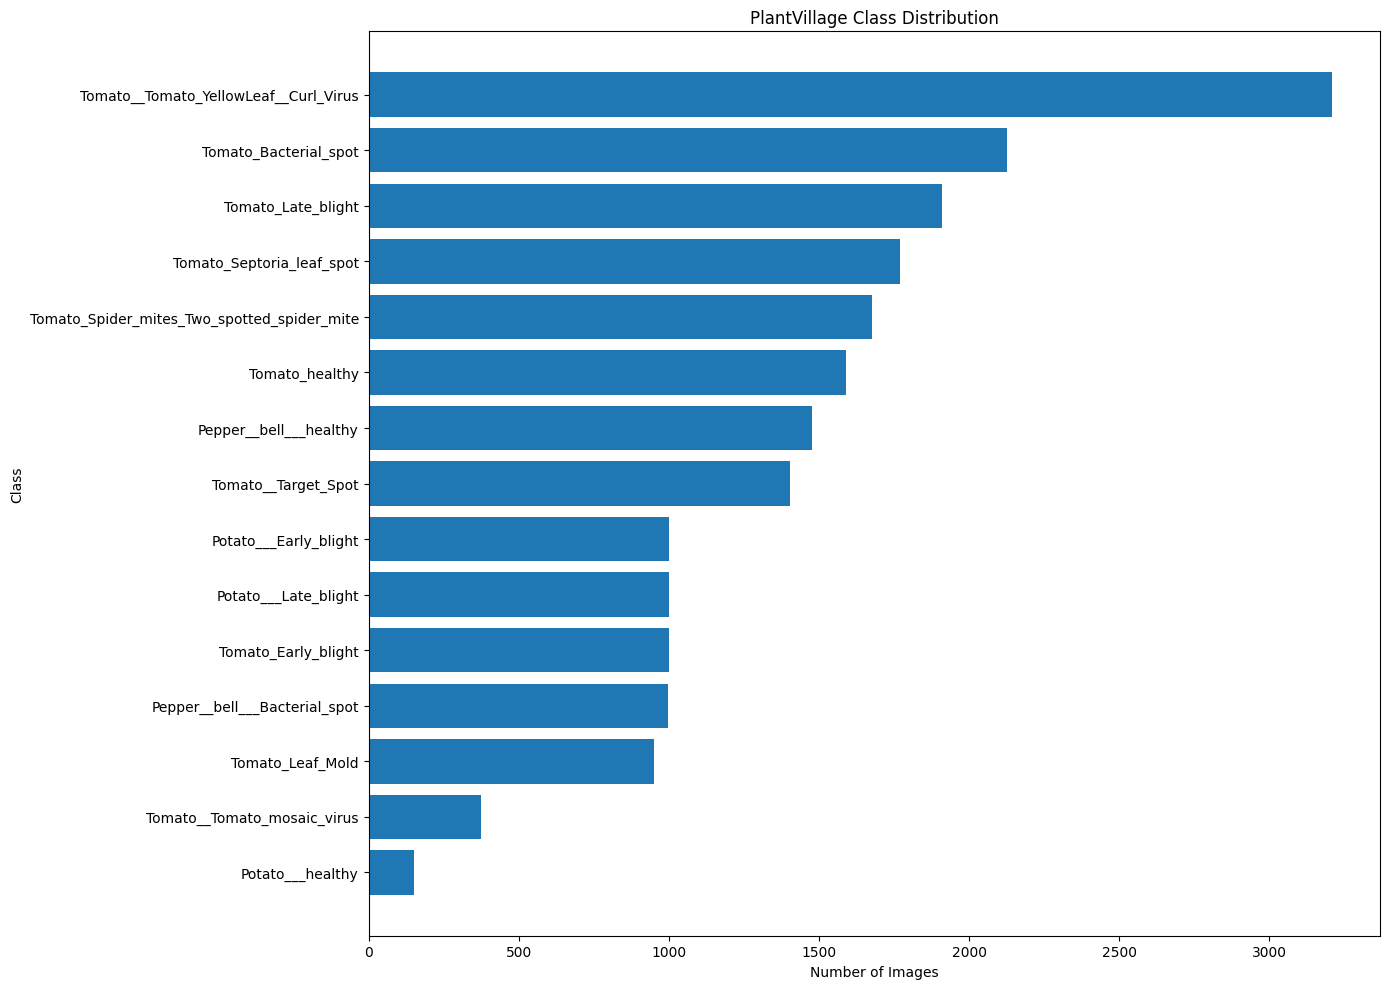

Saved to: /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/class_distribution.png


In [14]:
# CELL 14: PLOT CLASS DISTRIBUTION

plt.figure(figsize=(14, 10))

plt.barh(
    class_distribution["Class"],
    class_distribution["Image_Count"]
)

plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("PlantVillage Class Distribution")

plt.gca().invert_yaxis()

plt.tight_layout()

distribution_path = RESULTS_DIR / "class_distribution.png"
plt.savefig(distribution_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", distribution_path)

In [15]:
# CELL 16: CHECK IMAGE PROPERTIES

sample_records = []

for class_dir in class_dirs:
    image_files = [
        f for f in class_dir.rglob("*")
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Check up to 10 images per class
    for image_path in image_files[:10]:
        try:
            with Image.open(image_path) as img:
                sample_records.append({
                    "class": class_dir.name,
                    "width": img.width,
                    "height": img.height,
                    "mode": img.mode,
                    "format": img.format
                })
        except Exception as e:
            print("Error reading:", image_path, e)

image_properties = pd.DataFrame(sample_records)

print(image_properties.head())

print("\nImage modes:")
print(image_properties["mode"].value_counts())

print("\nImage formats:")
print(image_properties["format"].value_counts())

print("\nDimensions:")
print(
    image_properties.groupby(
        ["width", "height"]
    ).size().sort_values(ascending=False).head(20)
)

                           class  width  height mode format
0  Pepper__bell___Bacterial_spot    256     256  RGB   JPEG
1  Pepper__bell___Bacterial_spot    256     256  RGB   JPEG
2  Pepper__bell___Bacterial_spot    256     256  RGB   JPEG
3  Pepper__bell___Bacterial_spot    256     256  RGB   JPEG
4  Pepper__bell___Bacterial_spot    256     256  RGB   JPEG

Image modes:
mode
RGB    150
Name: count, dtype: int64

Image formats:
format
JPEG    150
Name: count, dtype: int64

Dimensions:
width  height
256    256       150
dtype: int64


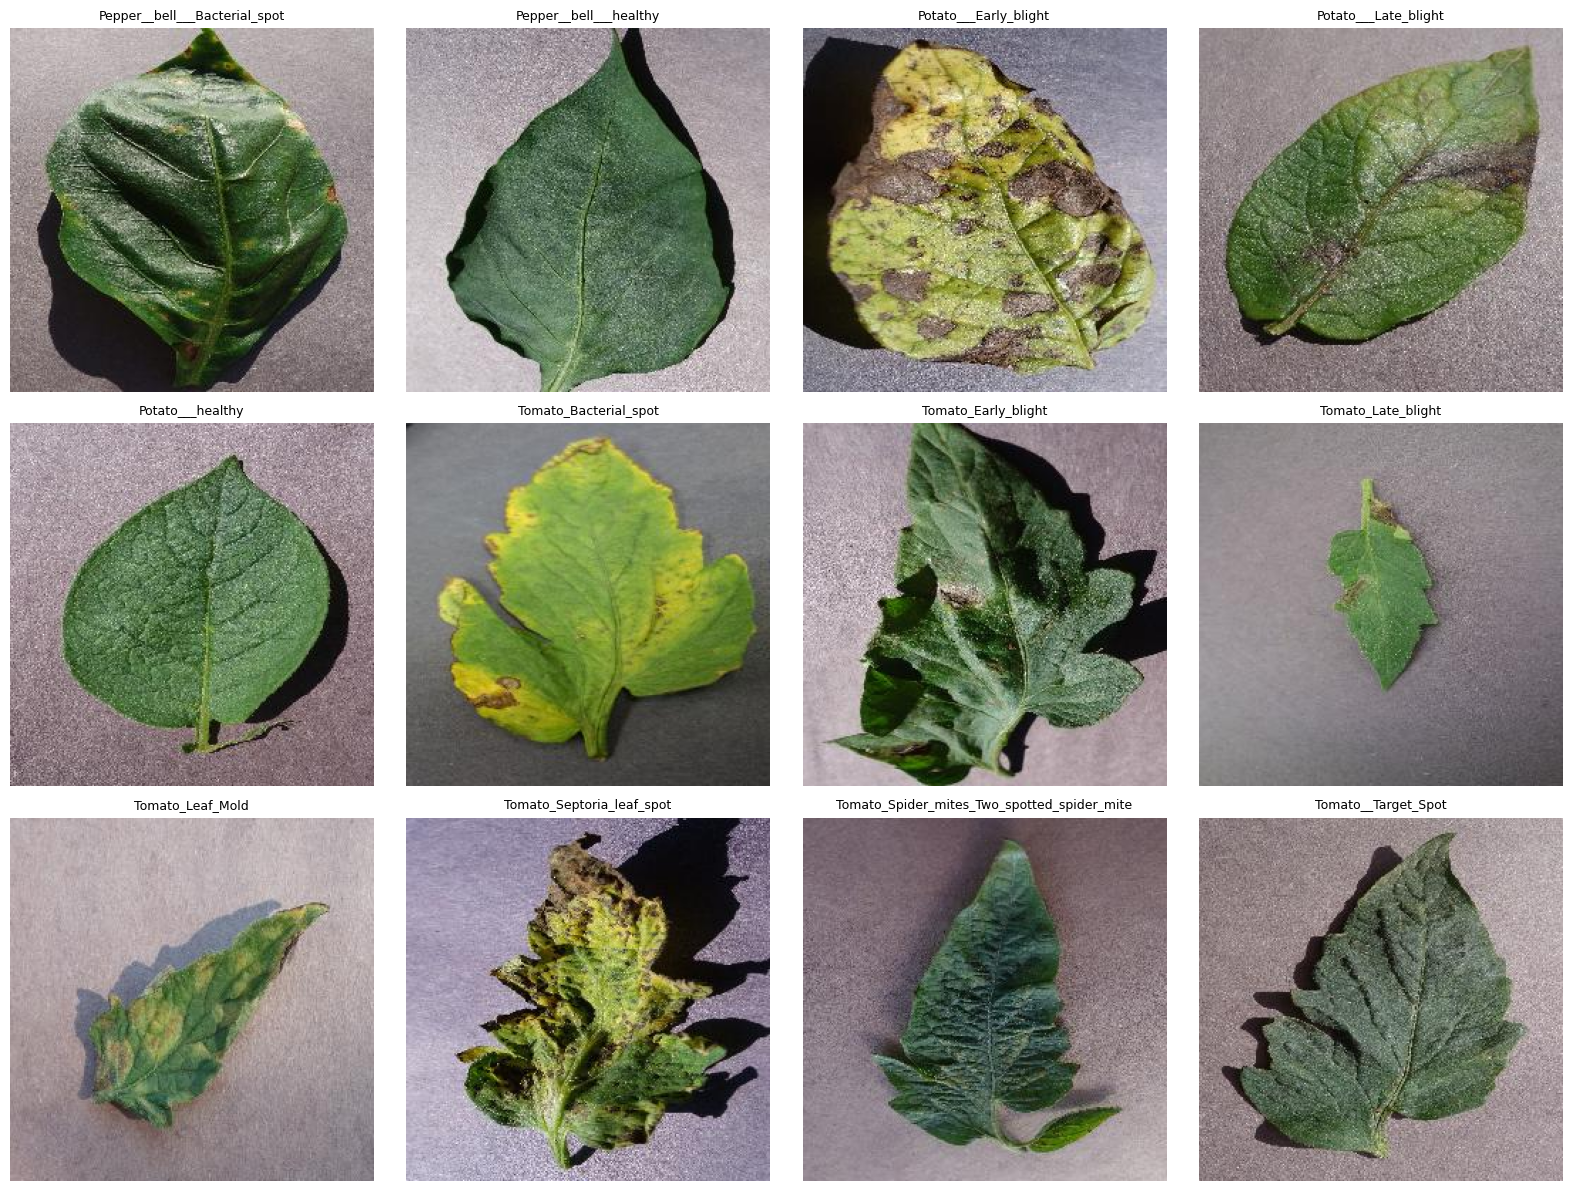

Saved to: /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/sample_images.png


In [16]:
# CELL 17: DISPLAY SAMPLE IMAGES

NUM_CLASSES_TO_DISPLAY = min(12, len(class_dirs))

fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12)
)

axes = axes.flatten()

for i, class_dir in enumerate(class_dirs[:NUM_CLASSES_TO_DISPLAY]):

    image_files = [
        f for f in class_dir.rglob("*")
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if not image_files:
        continue

    image_path = random.choice(image_files)

    image = Image.open(image_path).convert("RGB")

    axes[i].imshow(image)
    axes[i].set_title(class_dir.name, fontsize=9)
    axes[i].axis("off")

for j in range(NUM_CLASSES_TO_DISPLAY, len(axes)):
    axes[j].axis("off")

plt.tight_layout()

sample_path = RESULTS_DIR / "sample_images.png"
plt.savefig(sample_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", sample_path)

In [17]:
# CELL 18: CREATE IMAGE DATAFRAME

records = []

class_names = sorted([d.name for d in class_dirs])

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

for class_name in class_names:

    class_dir = PLANTVILLAGE_DIR / class_name

    image_files = [
        f for f in class_dir.rglob("*")
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for image_path in image_files:
        records.append({
            "filepath": str(image_path),
            "class": class_name,
            "label": class_to_index[class_name]
        })

df = pd.DataFrame(records)

print("Total records:", len(df))
print("Number of classes:", df["class"].nunique())

df.head()

Total records: 20638
Number of classes: 15


,filepath,class,label
0,/content/plantdisease/PlantVillage/Pepper__bel...,Pepper__bell___Bacterial_spot,0
1,/content/plantdisease/PlantVillage/Pepper__bel...,Pepper__bell___Bacterial_spot,0
2,/content/plantdisease/PlantVillage/Pepper__bel...,Pepper__bell___Bacterial_spot,0
3,/content/plantdisease/PlantVillage/Pepper__bel...,Pepper__bell___Bacterial_spot,0
4,/content/plantdisease/PlantVillage/Pepper__bel...,Pepper__bell___Bacterial_spot,0


In [18]:
# CELL 19: CHECK FOR CORRUPTED IMAGES

corrupted_files = []

for filepath in df["filepath"]:
    try:
        with Image.open(filepath) as img:
            img.verify()
    except Exception:
        corrupted_files.append(filepath)

print("Corrupted images:", len(corrupted_files))

if corrupted_files:
    print("\nFirst corrupted files:")
    for filepath in corrupted_files[:20]:
        print(filepath)

Corrupted images: 0


In [19]:
# CELL 20: TRAIN / VALIDATION / TEST SPLIT

train_df, temp_df = train_test_split(
    df,
    test_size=(VALIDATION_RATIO + TEST_RATIO),
    stratify=df["label"],
    random_state=SEED
)

relative_test_size = TEST_RATIO / (VALIDATION_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print("\nActual proportions:")
print("Train:", len(train_df) / len(df))
print("Validation:", len(val_df) / len(df))
print("Test:", len(test_df) / len(df))

Training images: 14446
Validation images: 3096
Testing images: 3096

Actual proportions:
Train: 0.6999709274154472
Validation: 0.15001453629227637
Test: 0.15001453629227637


In [20]:
# CELL 21: VERIFY STRATIFIED SPLITS

split_distribution = pd.DataFrame({
    "Train": train_df["class"].value_counts(),
    "Validation": val_df["class"].value_counts(),
    "Test": test_df["class"].value_counts()
}).fillna(0).astype(int)

split_distribution

,Train,Validation,Test
class,,,
Pepper__bell___Bacterial_spot,698,150,149
Pepper__bell___healthy,1035,222,221
Potato___Early_blight,700,150,150
Potato___Late_blight,700,150,150
Potato___healthy,106,23,23
Tomato_Bacterial_spot,1489,319,319
Tomato_Early_blight,700,150,150
Tomato_Late_blight,1336,286,287
Tomato_Leaf_Mold,666,143,143


In [21]:
# CELL 22: SAVE DATA SPLIT

train_df.to_csv(DATA_DIR / "train_split.csv", index=False)
val_df.to_csv(DATA_DIR / "validation_split.csv", index=False)
test_df.to_csv(DATA_DIR / "test_split.csv", index=False)

print("Saved:")
print(DATA_DIR / "train_split.csv")
print(DATA_DIR / "validation_split.csv")
print(DATA_DIR / "test_split.csv")

Saved:
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/data/train_split.csv
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/data/validation_split.csv
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/data/test_split.csv


In [22]:
# CELL 23: CREATE TENSORFLOW DATASETS

import gc

NUM_PARALLEL_CALLS = 2
PREFETCH_SIZE = 1
SHUFFLE_BUFFER = 1000

print("Dataset pipeline configuration:")
print("Parallel calls:", NUM_PARALLEL_CALLS)
print("Prefetch size:", PREFETCH_SIZE)
print("Shuffle buffer:", SHUFFLE_BUFFER)
print("Batch size:", BATCH_SIZE)

# Image loading function
def load_image(filepath, label):

    # Read image file from disk
    image = tf.io.read_file(filepath)

    # Decode image
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Explicitly set shape
    image.set_shape([None, None, 3])

    # Resize to EfficientNetB0 input size
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Convert to float32
    image = tf.cast(image, tf.float32)

    return image, label


# Dataset creation function
def create_dataset(dataframe, shuffle=False):

    paths = dataframe["filepath"].astype(str).values
    labels = dataframe["label"].astype(np.int32).values

    # Create dataset from file paths and labels.
    # Images themselves are NOT loaded into RAM here.
    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    # Read and resize images from disk.
    dataset = dataset.map(
        load_image,
        num_parallel_calls=NUM_PARALLEL_CALLS,
        deterministic=True
    )

    # Shuffle ONLY a limited number of file paths/images.
    # Do not use len(dataframe) as the buffer size.
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(SHUFFLE_BUFFER, len(dataframe)),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    # Create small batches
    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    # Only keep one batch ready in memory.
    dataset = dataset.prefetch(
        PREFETCH_SIZE
    )

    return dataset


# Clear any previous TensorFlow objects
gc.collect()


# Create datasets
train_dataset = create_dataset(
    train_df,
    shuffle=True
)

validation_dataset = create_dataset(
    val_df,
    shuffle=False
)

test_dataset = create_dataset(
    test_df,
    shuffle=False
)


print("\nTensorFlow datasets created successfully.")
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

Dataset pipeline configuration:
Parallel calls: 2
Prefetch size: 1
Shuffle buffer: 1000
Batch size: 8

TensorFlow datasets created successfully.
Training images: 14446
Validation images: 3096
Testing images: 3096


In [23]:
# CELL 23.1: TEST ONE BATCH

import psutil
import gc

gc.collect()

ram = psutil.virtual_memory()

print("RAM before loading one batch:")
print(f"Used:      {ram.used / (1024**3):.2f} GB")
print(f"Available: {ram.available / (1024**3):.2f} GB")

print("\nLoading one training batch...")

for images, labels in train_dataset.take(1):

    print("\nBatch loaded successfully!")
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

ram = psutil.virtual_memory()

print("\nRAM after loading one batch:")
print(f"Used:      {ram.used / (1024**3):.2f} GB")
print(f"Available: {ram.available / (1024**3):.2f} GB")

RAM before loading one batch:
Used:      1.95 GB
Available: 10.40 GB

Loading one training batch...

Batch loaded successfully!
Image shape: (8, 224, 224, 3)
Label shape: (8,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>

RAM after loading one batch:
Used:      1.96 GB
Available: 10.38 GB


In [24]:
# CELL 24: DATA AUGMENTATION

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal"
        ),

        tf.keras.layers.RandomRotation(
            factor=0.05
        ),

        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10
        ),

        tf.keras.layers.RandomContrast(
            factor=0.10
        )
    ],
    name="data_augmentation"
)

print("Data augmentation pipeline:")
data_augmentation.summary()

Data augmentation pipeline:


Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
# CELL 25: BUILD EFFICIENTNETB0

import gc

# Clear unused TensorFlow objects from memory
gc.collect()
tf.keras.backend.clear_session()

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Input size:", IMG_SIZE)


# EfficientNetB0 backbone
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)


# Freeze backbone for initial training
base_model.trainable = False


# Classification head
inputs = tf.keras.Input(
    shape=IMG_SIZE + (3,),
    name="input_image"
)

# Data augmentation
x = data_augmentation(inputs)

# EfficientNet backbone
x = base_model(
    x,
    training=False
)

# Global average pooling
x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

# Dropout
x = tf.keras.layers.Dropout(
    DROPOUT_RATE,
    name="dropout"
)(x)

# Final classification layer
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)


# Create final model
model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_PlantDisease"
)


print("\nEfficientNetB0 model created successfully.")
model.summary()

Number of classes: 15
Input size: (224, 224)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

EfficientNetB0 model created successfully.


Model: "EfficientNetB0_PlantDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [26]:
# CELL 26: MODEL PARAMETERS

trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.trainable_variables
])

non_trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.non_trainable_variables
])

total_params = trainable_params + non_trainable_params


print("Model parameter summary")
print("=" * 50)

print(
    f"Trainable parameters:     {trainable_params:,}"
)

print(
    f"Non-trainable parameters: {non_trainable_params:,}"
)

print(
    f"Total parameters:         {total_params:,}"
)

Model parameter summary
Trainable parameters:     19,215
Non-trainable parameters: 4,049,599.0
Total parameters:         4,068,814.0


In [27]:
# CELL 27: COMPILE MODEL

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LEARNING_RATE
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Model compiled successfully.")
print("Learning rate:", INITIAL_LEARNING_RATE)

Model compiled successfully.
Learning rate: 0.001


In [28]:
# CELL 28: TRAINING CALLBACKS

best_model_path = MODELS_DIR / "efficientnetb0_best_frozen.keras"

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured.")
print("Best model will be saved to:")
print(best_model_path)

Callbacks configured.
Best model will be saved to:
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/models/efficientnetb0_best_frozen.keras


In [29]:
# CELL 29: TRAIN FROZEN EFFICIENTNETB0

import gc
import psutil
import time

# ------------------------------------------------------------
# Garbage collection before training
# ------------------------------------------------------------

gc.collect()


# ------------------------------------------------------------
# Check RAM
# ------------------------------------------------------------

ram = psutil.virtual_memory()

print("RAM status before training:")
print(f"Total RAM:     {ram.total / (1024**3):.2f} GB")
print(f"Used RAM:      {ram.used / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")


# ------------------------------------------------------------
# Check GPU
# ------------------------------------------------------------

gpus = tf.config.list_physical_devices("GPU")

print("\nGPU devices:")

if gpus:
    for gpu in gpus:
        print(gpu)
else:
    print("WARNING: No GPU detected.")


# ------------------------------------------------------------
# Start training
# ------------------------------------------------------------

print("\nStarting frozen EfficientNetB0 training...")
print("=" * 60)

start_time = time.time()

history_frozen = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

frozen_training_time = time.time() - start_time


# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------

print("\n" + "=" * 60)

print(
    f"Frozen training completed in "
    f"{frozen_training_time / 60:.2f} minutes"
)

print("=" * 60)


# ------------------------------------------------------------
# RAM after training
# ------------------------------------------------------------

ram = psutil.virtual_memory()

print("\nRAM status after training:")
print(f"Used RAM:      {ram.used / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")

RAM status before training:
Total RAM:     12.67 GB
Used RAM:      2.06 GB
Available RAM: 10.28 GB

GPU devices:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Starting frozen EfficientNetB0 training...
Epoch 1/15
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6711 - loss: 1.1302
Epoch 1: val_accuracy improved from None to 0.88695, saving model to /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/models/efficientnetb0_best_frozen.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/models/efficientnetb0_best_frozen.keras
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.7893 - loss: 0.7328 - val_accuracy: 0.8870 - val_loss: 0.3851 - learning_rate: 0.0010
Epoch 2/15
1804/1806 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8868 - loss: 0.3842
Epoch 2: val_accuracy improved from 0.88695 to 0.90052, saving model to /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/models/efficientnetb0_bes

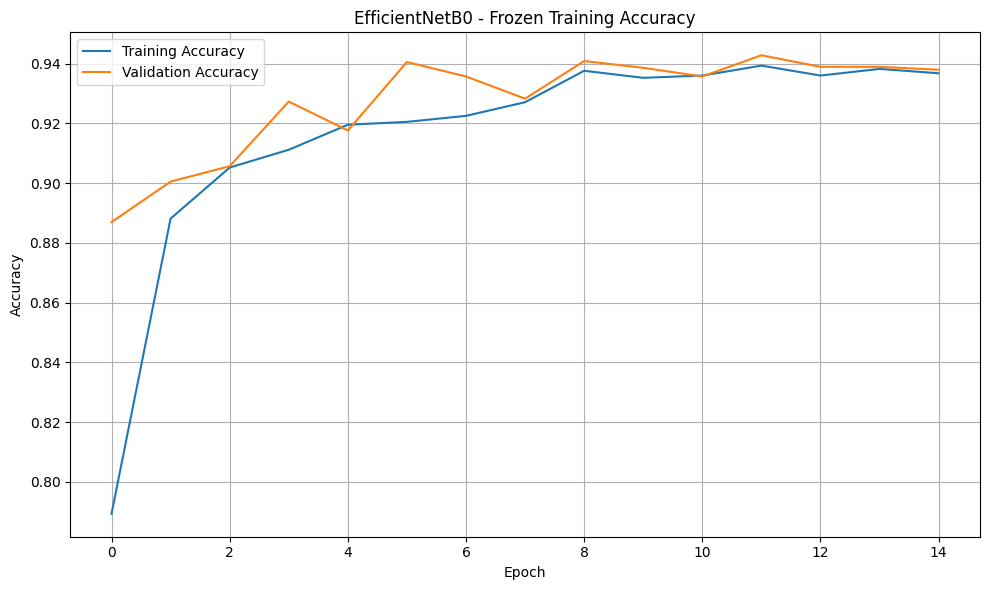

Saved to: /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/efficientnetb0_frozen_accuracy.png


In [30]:
# CELL 30: FROZEN TRAINING - ACCURACY CURVE

plt.figure(figsize=(10, 6))

plt.plot(
    history_frozen.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_frozen.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 - Frozen Training Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()

accuracy_path = RESULTS_DIR / "efficientnetb0_frozen_accuracy.png"

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", accuracy_path)

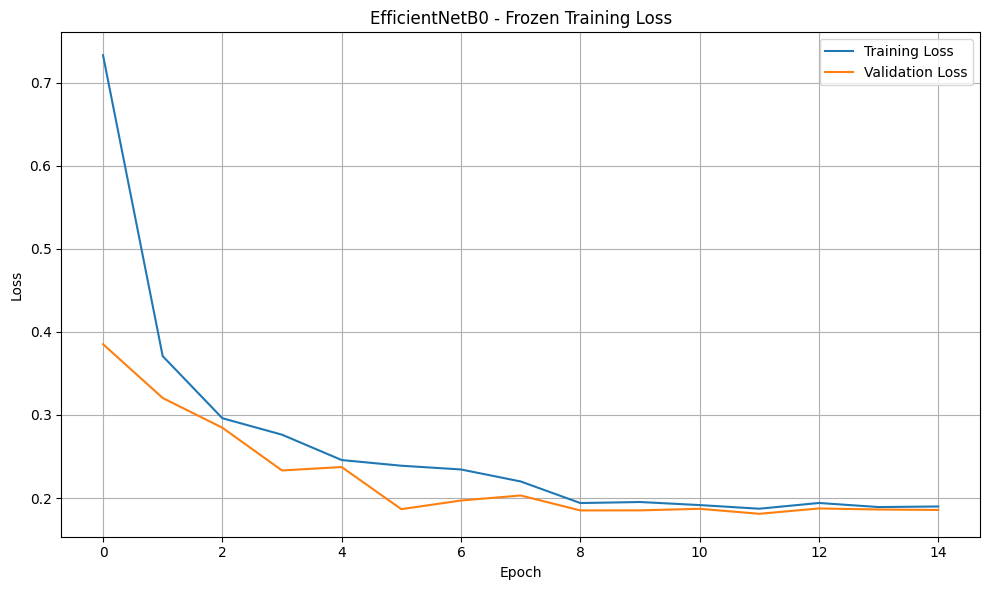

Saved to: /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/efficientnetb0_frozen_loss.png


In [31]:
# CELL 31: FROZEN TRAINING - LOSS CURVE

plt.figure(figsize=(10, 6))

plt.plot(
    history_frozen.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_frozen.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 - Frozen Training Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

loss_path = RESULTS_DIR / "efficientnetb0_frozen_loss.png"

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", loss_path)

In [32]:
# CELL 32: BEST FROZEN VALIDATION RESULT
best_frozen_epoch = np.argmax(
    history_frozen.history["val_accuracy"]
) + 1

best_frozen_val_accuracy = max(
    history_frozen.history["val_accuracy"]
)

best_frozen_val_loss = min(
    history_frozen.history["val_loss"]
)

print("Best Frozen EfficientNetB0 Result")
print("=" * 50)

print(
    f"Best Epoch:           {best_frozen_epoch}"
)

print(
    f"Validation Accuracy:  {best_frozen_val_accuracy:.4f}"
)

print(
    f"Validation Loss:      {best_frozen_val_loss:.4f}"
)

Best Frozen EfficientNetB0 Result
Best Epoch:           12
Validation Accuracy:  0.9428
Validation Loss:      0.1811


In [33]:
# CELL 33: PREPARE EFFICIENTNETB0 FOR FINE-TUNING

print("Preparing EfficientNetB0 for fine-tuning...")

# Unfreeze the EfficientNet backbone
base_model.trainable = True


# Freeze the first 70% of layers
total_base_layers = len(base_model.layers)

freeze_until = int(total_base_layers * 0.70)

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

for layer in base_model.layers[freeze_until:]:
    layer.trainable = True


# Count trainable / non-trainable parameters
trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.trainable_variables
])

non_trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.non_trainable_variables
])

total_params = trainable_params + non_trainable_params


print("\nFine-tuning configuration")
print("=" * 50)

print("Total EfficientNet layers:", total_base_layers)
print("Frozen layers:", freeze_until)
print(
    "Trainable backbone layers:",
    total_base_layers - freeze_until
)

print("\nParameters:")
print(
    f"Trainable parameters:     {trainable_params:,}"
)

print(
    f"Non-trainable parameters: {non_trainable_params:,}"
)

print(
    f"Total parameters:         {total_params:,}"
)

Preparing EfficientNetB0 for fine-tuning...

Fine-tuning configuration
Total EfficientNet layers: 238
Frozen layers: 166
Trainable backbone layers: 72

Parameters:
Trainable parameters:     3,098,347
Non-trainable parameters: 970,467.0
Total parameters:         4,068,814.0


In [34]:
# CELL 33.1: KEEP BATCH NORMALIZATION LAYERS FROZEN

for layer in base_model.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

print("Batch Normalization layers kept frozen.")

Batch Normalization layers kept frozen.


In [35]:
# CELL 34: COMPILE MODEL FOR FINE-TUNING

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LEARNING_RATE
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Model compiled for fine-tuning.")
print(
    "Fine-tuning learning rate:",
    FINE_TUNE_LEARNING_RATE
)

Model compiled for fine-tuning.
Fine-tuning learning rate: 1e-05


In [36]:
# CELL 35: FINE-TUNING CALLBACKS

fine_tuned_model_path = (
    MODELS_DIR / "efficientnetb0_best_finetuned.keras"
)

fine_tune_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(fine_tuned_model_path),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

print("Fine-tuning callbacks configured.")
print("Best model:")
print(fine_tuned_model_path)

Fine-tuning callbacks configured.
Best model:
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/models/efficientnetb0_best_finetuned.keras


In [37]:
# CELL 36: FINE-TUNE EFFICIENTNETB0

import gc
import psutil
import time

gc.collect()

ram = psutil.virtual_memory()

print("RAM before fine-tuning:")
print(
    f"Used:      {ram.used / (1024**3):.2f} GB"
)

print(
    f"Available: {ram.available / (1024**3):.2f} GB"
)

print("\nStarting EfficientNetB0 fine-tuning...")
print("=" * 60)

fine_tune_start = time.time()

history_finetune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks,
    verbose=1
)

fine_tuning_time = time.time() - fine_tune_start

print("\n" + "=" * 60)

print(
    f"Fine-tuning completed in "
    f"{fine_tuning_time / 60:.2f} minutes"
)

print("=" * 60)

ram = psutil.virtual_memory()

print("\nRAM after fine-tuning:")
print(
    f"Used:      {ram.used / (1024**3):.2f} GB"
)

print(
    f"Available: {ram.available / (1024**3):.2f} GB"
)

RAM before fine-tuning:
Used:      2.67 GB
Available: 9.65 GB

Starting EfficientNetB0 fine-tuning...
Epoch 1/10
1805/1806 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9405 - loss: 0.1762
Epoch 1: val_accuracy improved from None to 0.94638, saving model to /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/models/efficientnetb0_best_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/models/efficientnetb0_best_finetuned.keras
1806/1806 ━━━━━━━━━━━━━━━━━━━━ 105s 50ms/step - accuracy: 0.9460 - loss: 0.1606 - val_accuracy: 0.9464 - val_loss: 0.1590 - learning_rate: 1.0000e-05
Epoch 2/10
1805/1806 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9602 - loss: 0.1217
Epoch 2: val_accuracy improved from 0.94638 to 0.95187, saving model to /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/models/efficientnetb0_best_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB

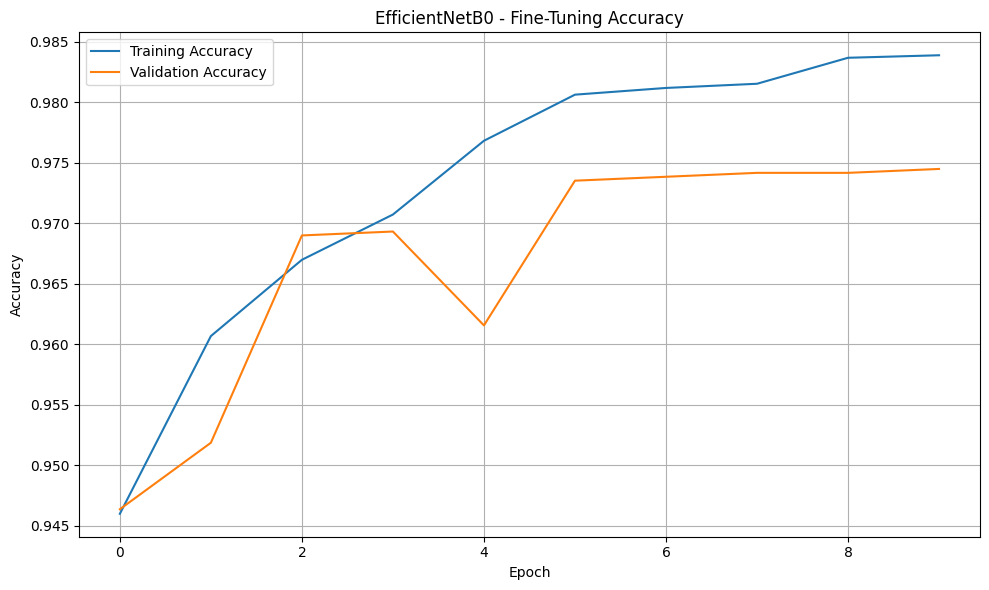

Saved to: /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/efficientnetb0_finetune_accuracy.png


In [38]:
# CELL 37: FINE-TUNING ACCURACY CURVE

plt.figure(figsize=(10, 6))

plt.plot(
    history_finetune.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_finetune.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "EfficientNetB0 - Fine-Tuning Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

path = RESULTS_DIR / "efficientnetb0_finetune_accuracy.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", path)

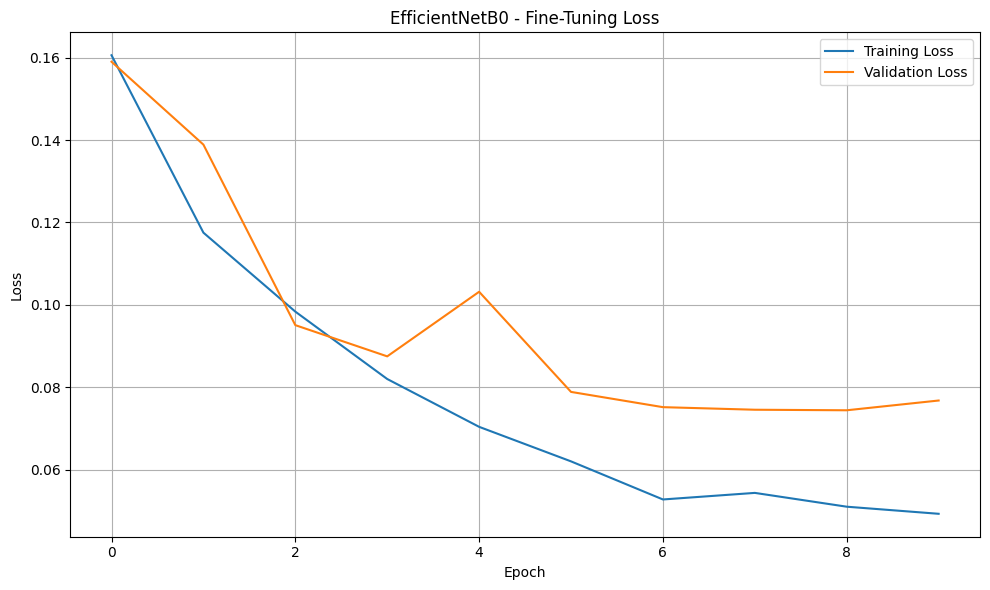

Saved to: /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/efficientnetb0_finetune_loss.png


In [39]:
# CELL 38: FINE-TUNING LOSS CURVE

plt.figure(figsize=(10, 6))

plt.plot(
    history_finetune.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_finetune.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "EfficientNetB0 - Fine-Tuning Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

path = RESULTS_DIR / "efficientnetb0_finetune_loss.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", path)

In [40]:
# CELL 39: LOAD BEST FINE-TUNED MODEL

print("Loading best fine-tuned EfficientNetB0 model...")

best_model = tf.keras.models.load_model(
    str(fine_tuned_model_path)
)

print("Best model loaded successfully.")

best_model.summary()

Loading best fine-tuned EfficientNetB0 model...
Best model loaded successfully.


Model: "EfficientNetB0_PlantDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,216,458 (38.97 MB)

 Trainable params: 3,073,835 (11.73 MB)

 Non-trainable params: 994,951 (3.80 MB)

 Optimizer params: 6,147,672 (23.45 MB)

In [41]:
# CELL 40: FINAL VALIDATION EVALUATION

print("Evaluating final model on validation data...")

validation_results = best_model.evaluate(
    validation_dataset,
    verbose=1
)

validation_loss = validation_results[0]
validation_accuracy = validation_results[1]

print("\nFinal Validation Results")
print("=" * 50)

print(
    f"Validation Loss:      {validation_loss:.4f}"
)

print(
    f"Validation Accuracy:  {validation_accuracy:.4f}"
)

Evaluating final model on validation data...
387/387 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9745 - loss: 0.0768

Final Validation Results
Validation Loss:      0.0768
Validation Accuracy:  0.9745


In [42]:
# CELL 41: FINAL TEST EVALUATION

print("FINAL TEST EVALUATION")
print("=" * 60)

print(
    "The test set is being used for the final evaluation."
)

test_results = best_model.evaluate(
    test_dataset,
    verbose=1
)

test_loss = test_results[0]
test_accuracy = test_results[1]

print("\nFinal Test Results")
print("=" * 50)

print(
    f"Test Loss:      {test_loss:.4f}"
)

print(
    f"Test Accuracy:  {test_accuracy:.4f}"
)

FINAL TEST EVALUATION
The test set is being used for the final evaluation.
387/387 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9748 - loss: 0.0818

Final Test Results
Test Loss:      0.0818
Test Accuracy:  0.9748


In [43]:
# CELL 42: GENERATE TEST PREDICTIONS

print("Generating test predictions...")

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_labels
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated.")

print("Number of test samples:", len(y_true))

Generating test predictions...
Predictions generated.
Number of test samples: 3096


In [44]:
# CELL 43: CLASSIFICATION REPORT

classification_report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(classification_report_text)


# Save report

report_path = (
    RESULTS_DIR /
    "efficientnetb0_classification_report.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        classification_report_text
    )

print("\nClassification report saved to:")
print(report_path)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9739    1.0000    0.9868       149
                     Pepper__bell___healthy     0.9954    0.9819    0.9886       221
                      Potato___Early_blight     0.9868    1.0000    0.9934       150
                       Potato___Late_blight     0.9933    0.9867    0.9900       150
                           Potato___healthy     1.0000    0.9565    0.9778        23
                      Tomato_Bacterial_spot     0.9936    0.9781    0.9858       319
                        Tomato_Early_blight     0.9919    0.8133    0.8938       150
                         Tomato_Late_blight     0.9694    0.9930    0.9811       287
                           Tomato_Leaf_Mold     0.9928    0.9580    0.9751       143
                  Tomato_Septoria_leaf_spot     0.9809    0.9662    0.9735       266
Tomato_Spider_mites_Two_spotted_spider_mite     0.9717    0.9524

In [45]:
# CELL 44: FINAL METRICS

final_accuracy = accuracy_score(
    y_true,
    y_pred
)

final_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

final_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

final_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


print("EfficientNetB0 Final Test Metrics")
print("=" * 60)

print(
    f"Accuracy:          {final_accuracy:.4f}"
)

print(
    f"Macro Precision:   {final_precision:.4f}"
)

print(
    f"Macro Recall:      {final_recall:.4f}"
)

print(
    f"Macro F1-score:    {final_f1:.4f}"
)

EfficientNetB0 Final Test Metrics
Accuracy:          0.9748
Macro Precision:   0.9778
Macro Recall:      0.9711
Macro F1-score:    0.9734


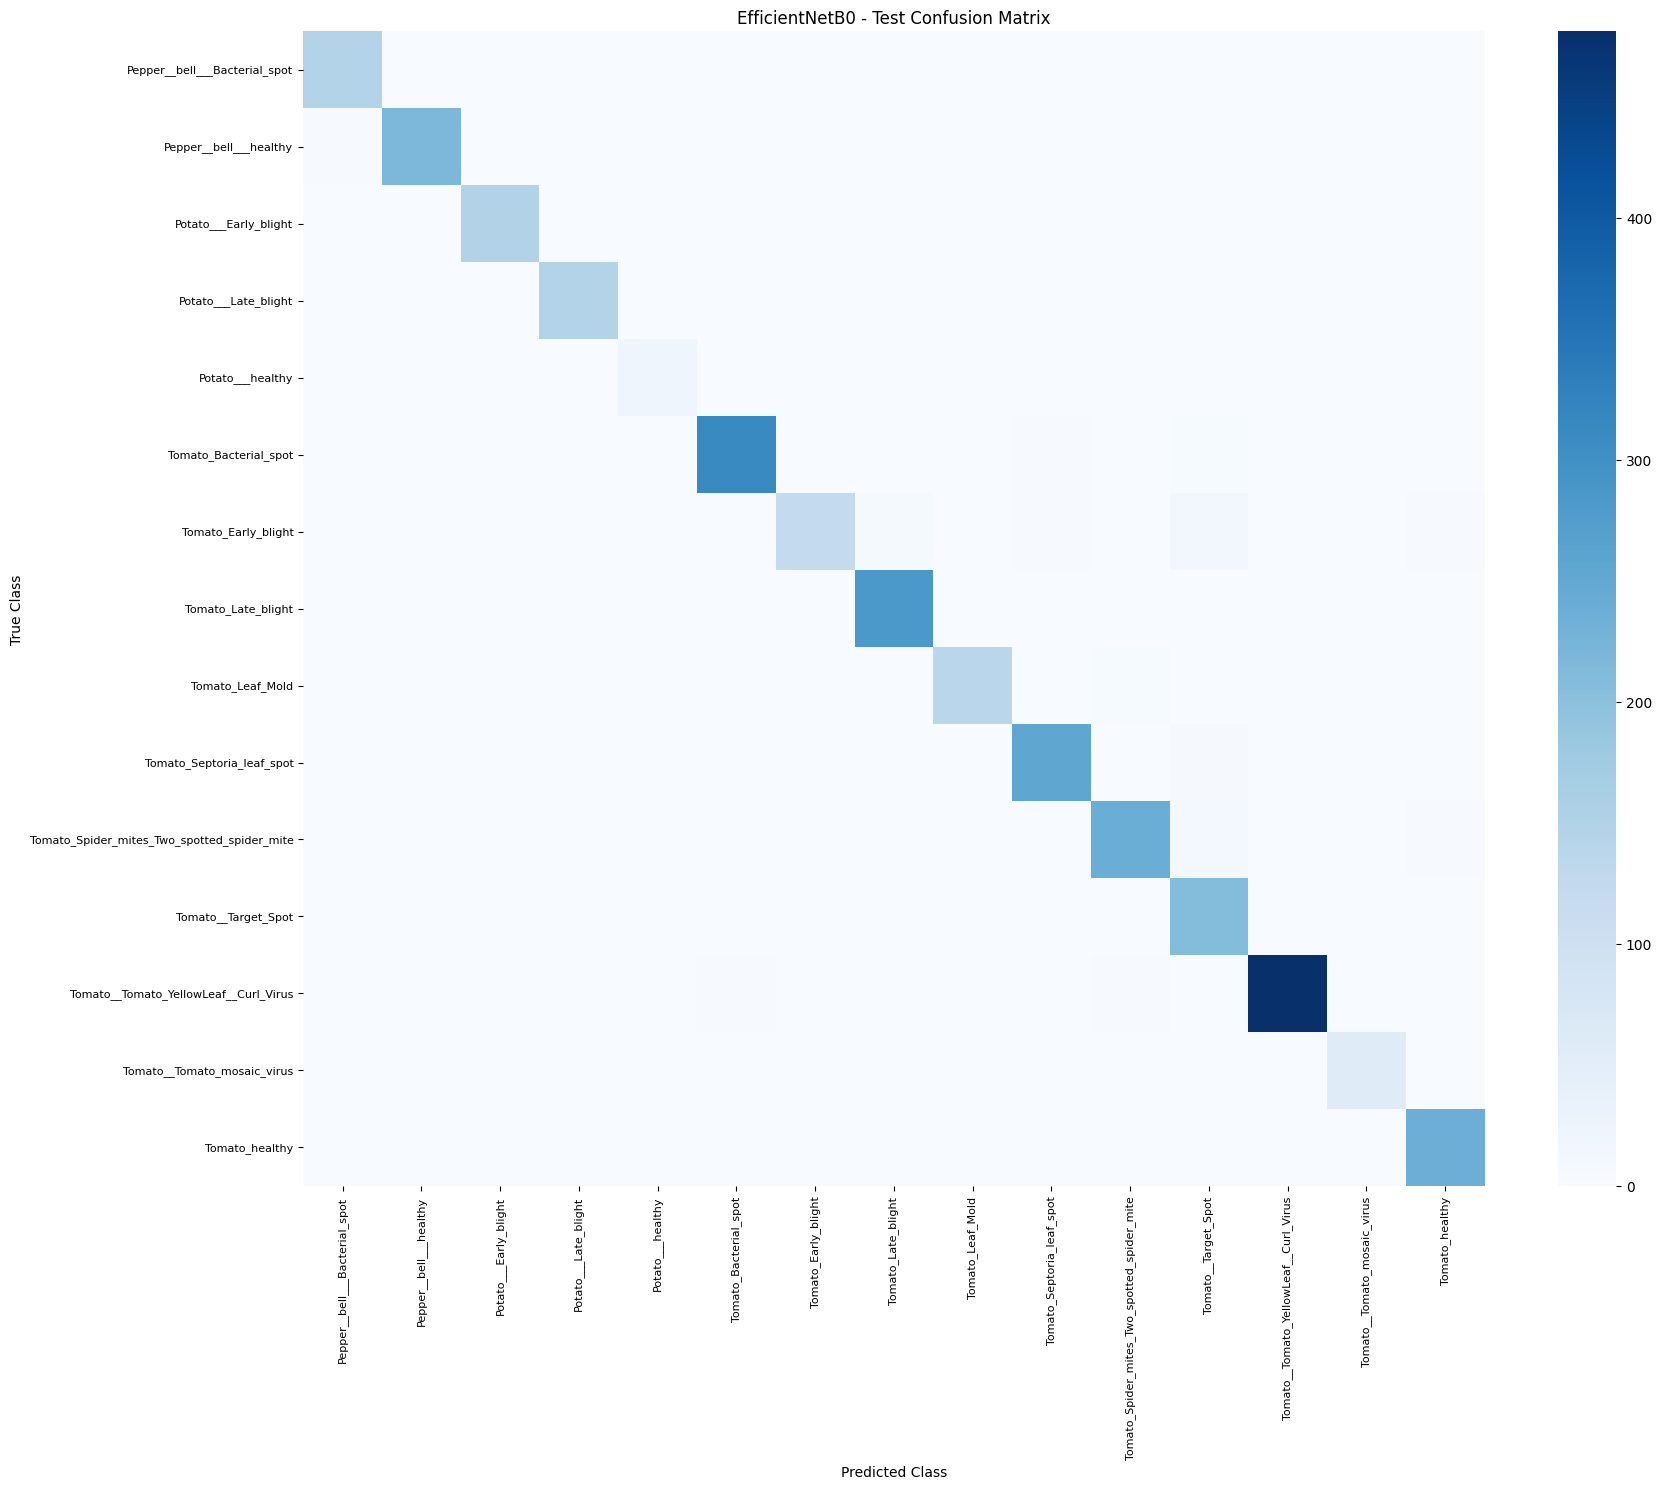

Confusion matrix saved to:
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/efficientnetb0_confusion_matrix.png


In [46]:
# CELL 45: CONFUSION MATRIX

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(18, 15)
)

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.title(
    "EfficientNetB0 - Test Confusion Matrix"
)

plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)

plt.tight_layout()

cm_path = (
    RESULTS_DIR /
    "efficientnetb0_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(cm_path)

In [47]:
# CELL 46: MOST CONFUSED CLASS PAIRS

confusion_pairs = []

for i in range(len(class_names)):

    for j in range(len(class_names)):

        if i != j and cm[i, j] > 0:

            confusion_pairs.append({
                "True_Class": class_names[i],
                "Predicted_Class": class_names[j],
                "Count": int(cm[i, j])
            })


confusion_pairs_df = pd.DataFrame(
    confusion_pairs
).sort_values(
    "Count",
    ascending=False
).reset_index(drop=True)


print("Most confused class pairs:")
print()

display(
    confusion_pairs_df.head(20)
)


confusion_pairs_path = (
    RESULTS_DIR /
    "efficientnetb0_confusion_pairs.csv"
)

confusion_pairs_df.to_csv(
    confusion_pairs_path,
    index=False
)

print("\nSaved to:")
print(confusion_pairs_path)

Most confused class pairs:



,True_Class,Predicted_Class,Count
0,Tomato_Early_blight,Tomato__Target_Spot,15
1,Tomato_Spider_mites_Two_spotted_spider_mite,Tomato__Target_Spot,10
2,Tomato_Early_blight,Tomato_Late_blight,8
3,Tomato_Septoria_leaf_spot,Tomato__Target_Spot,6
4,Tomato_Bacterial_spot,Tomato__Target_Spot,4
5,Tomato_Leaf_Mold,Tomato_Spider_mites_Two_spotted_spider_mite,4
6,Tomato_Early_blight,Tomato_Septoria_leaf_spot,3
7,Pepper__bell___healthy,Pepper__bell___Bacterial_spot,3
8,Tomato_Spider_mites_Two_spotted_spider_mite,Tomato_healthy,2
9,Tomato_Bacterial_spot,Tomato_Septoria_leaf_spot,2



Saved to:
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/efficientnetb0_confusion_pairs.csv


In [48]:
# CELL 47: CREATE INCORRECT PREDICTION DATAFRAME

incorrect_indices = np.where(
    y_true != y_pred
)[0]


incorrect_df = test_df.iloc[
    incorrect_indices
].copy()


incorrect_df["true_label"] = [
    class_names[label]
    for label in y_true[incorrect_indices]
]

incorrect_df["predicted_label"] = [
    class_names[label]
    for label in y_pred[incorrect_indices]
]


print(
    "Incorrect predictions:",
    len(incorrect_df)
)

print(
    "Total test samples:",
    len(test_df)
)

print(
    f"Error rate: "
    f"{len(incorrect_df) / len(test_df):.4f}"
)

display(
    incorrect_df.head(20)
)

Incorrect predictions: 78
Total test samples: 3096
Error rate: 0.0252


,filepath,class,label,true_label,predicted_label
66,/content/plantdisease/PlantVillage/Potato___La...,Potato___Late_blight,3,Potato___Late_blight,Tomato__Target_Spot
70,/content/plantdisease/PlantVillage/Tomato_Earl...,Tomato_Early_blight,6,Tomato_Early_blight,Tomato__Target_Spot
81,/content/plantdisease/PlantVillage/Tomato_Earl...,Tomato_Early_blight,6,Tomato_Early_blight,Tomato__Target_Spot
140,/content/plantdisease/PlantVillage/Tomato_Spid...,Tomato_Spider_mites_Two_spotted_spider_mite,10,Tomato_Spider_mites_Two_spotted_spider_mite,Tomato_healthy
175,/content/plantdisease/PlantVillage/Tomato_Leaf...,Tomato_Leaf_Mold,8,Tomato_Leaf_Mold,Tomato_Spider_mites_Two_spotted_spider_mite
213,/content/plantdisease/PlantVillage/Tomato_Spid...,Tomato_Spider_mites_Two_spotted_spider_mite,10,Tomato_Spider_mites_Two_spotted_spider_mite,Tomato__Target_Spot
214,/content/plantdisease/PlantVillage/Tomato_heal...,Tomato_healthy,14,Tomato_healthy,Pepper__bell___healthy
302,/content/plantdisease/PlantVillage/Tomato__Tom...,Tomato__Tomato_YellowLeaf__Curl_Virus,12,Tomato__Tomato_YellowLeaf__Curl_Virus,Tomato__Target_Spot
321,/content/plantdisease/PlantVillage/Tomato_Sept...,Tomato_Septoria_leaf_spot,9,Tomato_Septoria_leaf_spot,Pepper__bell___Bacterial_spot
328,/content/plantdisease/PlantVillage/Tomato_Spid...,Tomato_Spider_mites_Two_spotted_spider_mite,10,Tomato_Spider_mites_Two_spotted_spider_mite,Tomato__Target_Spot


In [49]:
# CELL 49: MODEL COMPLEXITY

trainable_params = np.sum([
    np.prod(v.shape)
    for v in best_model.trainable_variables
])

non_trainable_params = np.sum([
    np.prod(v.shape)
    for v in best_model.non_trainable_variables
])

total_params = (
    trainable_params +
    non_trainable_params
)


print("EfficientNetB0 Model Complexity")
print("=" * 50)

print(
    f"Trainable parameters:     {trainable_params:,}"
)

print(
    f"Non-trainable parameters: {non_trainable_params:,}"
)

print(
    f"Total parameters:         {total_params:,}"
)

EfficientNetB0 Model Complexity
Trainable parameters:     3,073,835
Non-trainable parameters: 994,979.0
Total parameters:         4,068,814.0


In [50]:
# CELL 50: INFERENCE TIME

import time

# Get one batch
for sample_images, sample_labels in test_dataset.take(1):
    break


# Warm-up prediction
_ = best_model.predict(
    sample_images,
    verbose=0
)


# Timed prediction
start_time = time.time()

_ = best_model.predict(
    sample_images,
    verbose=0
)

inference_time = time.time() - start_time


batch_size_actual = sample_images.shape[0]

time_per_image = (
    inference_time /
    batch_size_actual
)


print("Inference Performance")
print("=" * 50)

print(
    f"Batch size:             {batch_size_actual}"
)

print(
    f"Batch inference time:   "
    f"{inference_time:.4f} seconds"
)

print(
    f"Time per image:         "
    f"{time_per_image:.6f} seconds"
)

print(
    f"Images per second:      "
    f"{1 / time_per_image:.2f}"
)

Inference Performance
Batch size:             8
Batch inference time:   0.1465 seconds
Time per image:         0.018311 seconds
Images per second:      54.61


In [51]:
# CELL 51: SAVE FINAL RESULTS

final_results = {

    "model": "EfficientNetB0",

    "dataset": "PlantVillage",

    "num_classes": int(NUM_CLASSES),

    "image_size": list(IMG_SIZE),

    "batch_size": int(BATCH_SIZE),

    "train_images": int(len(train_df)),

    "validation_images": int(len(val_df)),

    "test_images": int(len(test_df)),

    "frozen_training_time_minutes":
        float(frozen_training_time / 60),

    "fine_tuning_time_minutes":
        float(fine_tuning_time / 60),

    "test_loss":
        float(test_loss),

    "test_accuracy":
        float(final_accuracy),

    "macro_precision":
        float(final_precision),

    "macro_recall":
        float(final_recall),

    "macro_f1":
        float(final_f1),

    "trainable_parameters":
        int(trainable_params),

    "non_trainable_parameters":
        int(non_trainable_params),

    "total_parameters":
        int(total_params),

    "inference_time_per_image_seconds":
        float(time_per_image),

    "images_per_second":
        float(1 / time_per_image)
}


results_json_path = (
    RESULTS_DIR /
    "efficientnetb0_final_results.json"
)


with open(
    results_json_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_results,
        f,
        indent=4
    )


print("Final results saved to:")
print(results_json_path)

print("\nFinal results:")
print(
    json.dumps(
        final_results,
        indent=4
    )
)

Final results saved to:
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/efficientnetb0_final_results.json

Final results:
{
    "model": "EfficientNetB0",
    "dataset": "PlantVillage",
    "num_classes": 15,
    "image_size": [
        224,
        224
    ],
    "batch_size": 8,
    "train_images": 14446,
    "validation_images": 3096,
    "test_images": 3096,
    "frozen_training_time_minutes": 17.821665024757387,
    "fine_tuning_time_minutes": 14.808977345625559,
    "test_loss": 0.08178989589214325,
    "test_accuracy": 0.9748062015503876,
    "macro_precision": 0.9778445430876079,
    "macro_recall": 0.9711174180917066,
    "macro_f1": 0.9733669274874558,
    "trainable_parameters": 3073835,
    "non_trainable_parameters": 994979,
    "total_parameters": 4068814,
    "inference_time_per_image_seconds": 0.01831108331680298,
    "images_per_second": 54.61173338020696
}


In [52]:
# CELL 52: SAVE EXPERIMENT CONFIGURATION

experiment_config = {

    "model": "EfficientNetB0",

    "seed": SEED,

    "image_size": list(IMG_SIZE),

    "batch_size": BATCH_SIZE,

    "initial_epochs": INITIAL_EPOCHS,

    "fine_tune_epochs": FINE_TUNE_EPOCHS,

    "initial_learning_rate":
        INITIAL_LEARNING_RATE,

    "fine_tune_learning_rate":
        FINE_TUNE_LEARNING_RATE,

    "dropout_rate":
        DROPOUT_RATE,

    "train_ratio":
        TRAIN_RATIO,

    "validation_ratio":
        VALIDATION_RATIO,

    "test_ratio":
        TEST_RATIO,

    "num_classes":
        NUM_CLASSES,

    "shuffle_buffer":
        SHUFFLE_BUFFER,

    "parallel_calls":
        NUM_PARALLEL_CALLS,

    "prefetch_size":
        PREFETCH_SIZE,

    "fine_tuning_strategy":
        "First 70% of EfficientNetB0 layers frozen; "
        "remaining layers fine-tuned",

    "batch_normalization":
        "Frozen during fine-tuning"
}


config_path = (
    CONFIG_DIR /
    "efficientnetb0_experiment_config.json"
)


with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        experiment_config,
        f,
        indent=4
    )


print("Experiment configuration saved to:")
print(config_path)

Experiment configuration saved to:
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/configs/efficientnetb0_experiment_config.json


In [53]:
# CELL 53: SAVE ERROR ANALYSIS DATA

incorrect_predictions_path = (
    RESULTS_DIR /
    "efficientnetb0_incorrect_predictions.csv"
)

incorrect_df.to_csv(
    incorrect_predictions_path,
    index=False
)

print(
    "Incorrect prediction data saved to:"
)

print(
    incorrect_predictions_path
)

Incorrect prediction data saved to:
/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/efficientnetb0_incorrect_predictions.csv


In [54]:
# CELL 54: FINAL EXPERIMENT SUMMARY

print("=" * 70)
print("EFFICIENTNETB0 EXPERIMENT SUMMARY")
print("=" * 70)

print(f"Model:                 EfficientNetB0")
print(f"Dataset:               PlantVillage")
print(f"Number of classes:     {NUM_CLASSES}")

print("\nDataset Split")
print("-" * 40)

print(f"Training images:       {len(train_df)}")
print(f"Validation images:     {len(val_df)}")
print(f"Test images:           {len(test_df)}")

print("\nTraining")
print("-" * 40)

print(
    f"Frozen training time:  "
    f"{frozen_training_time / 60:.2f} min"
)

print(
    f"Fine-tuning time:      "
    f"{fine_tuning_time / 60:.2f} min"
)

print("\nFinal Test Performance")
print("-" * 40)

print(
    f"Accuracy:              "
    f"{final_accuracy:.4f}"
)

print(
    f"Macro Precision:       "
    f"{final_precision:.4f}"
)

print(
    f"Macro Recall:          "
    f"{final_recall:.4f}"
)

print(
    f"Macro F1:              "
    f"{final_f1:.4f}"
)

print("\nModel Complexity")
print("-" * 40)

print(
    f"Total parameters:      "
    f"{total_params:,}"
)

print("\nInference")
print("-" * 40)

print(
    f"Time/image:            "
    f"{time_per_image:.6f} sec"
)

print(
    f"Images/sec:            "
    f"{1 / time_per_image:.2f}"
)

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETED")
print("=" * 70)

EFFICIENTNETB0 EXPERIMENT SUMMARY
Model:                 EfficientNetB0
Dataset:               PlantVillage
Number of classes:     15

Dataset Split
----------------------------------------
Training images:       14446
Validation images:     3096
Test images:           3096

Training
----------------------------------------
Frozen training time:  17.82 min
Fine-tuning time:      14.81 min

Final Test Performance
----------------------------------------
Accuracy:              0.9748
Macro Precision:       0.9778
Macro Recall:          0.9711
Macro F1:              0.9734

Model Complexity
----------------------------------------
Total parameters:      4,068,814.0

Inference
----------------------------------------
Time/image:            0.018311 sec
Images/sec:            54.61

EXPERIMENT COMPLETED


In [55]:
# BASELINE VS FINE-TUNED VALIDATION COMPARISON

baseline_best_val_acc = max(
    history_frozen.history["val_accuracy"]
)

baseline_best_val_loss = min(
    history_frozen.history["val_loss"]
)

finetuned_best_val_acc = max(
    history_finetune.history["val_accuracy"]
)

finetuned_best_val_loss = min(
    history_finetune.history["val_loss"]
)

accuracy_improvement = (
    finetuned_best_val_acc -
    baseline_best_val_acc
)

print("=" * 60)
print("EFFICIENTNETB0: BASELINE VS FINE-TUNED")
print("=" * 60)

print(f"\nBaseline:")
print(f"Best Validation Accuracy: {baseline_best_val_acc:.4f}")
print(f"Best Validation Loss:     {baseline_best_val_loss:.4f}")

print(f"\nFine-Tuned:")
print(f"Best Validation Accuracy: {finetuned_best_val_acc:.4f}")
print(f"Best Validation Loss:     {finetuned_best_val_loss:.4f}")

print("\nImprovement:")
print(
    f"Validation Accuracy Gain: "
    f"{accuracy_improvement * 100:.2f} percentage points"
)

print(
    f"Validation Loss Reduction: "
    f"{baseline_best_val_loss - finetuned_best_val_loss:.4f}"
)

EFFICIENTNETB0: BASELINE VS FINE-TUNED

Baseline:
Best Validation Accuracy: 0.9428
Best Validation Loss:     0.1811

Fine-Tuned:
Best Validation Accuracy: 0.9745
Best Validation Loss:     0.0745

Improvement:
Validation Accuracy Gain: 3.17 percentage points
Validation Loss Reduction: 0.1066


In [59]:
BASELINE_MODEL_PATH = "/content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/models/efficientnetb0_best_frozen.keras"

In [60]:
# LOAD FROZEN BASELINE MODEL

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("Loading frozen baseline model...")

baseline_model = tf.keras.models.load_model(
    BASELINE_MODEL_PATH,
    compile=False
)

print("Baseline model loaded successfully.")

Loading frozen baseline model...
Baseline model loaded successfully.


In [61]:
# BASELINE VALIDATION PREDICTIONS

print("Generating baseline validation predictions...")

baseline_probabilities = baseline_model.predict(
    validation_dataset,
    verbose=1
)

baseline_predictions = np.argmax(
    baseline_probabilities,
    axis=1
)

baseline_true_labels = np.concatenate([
    y.numpy()
    for x, y in validation_dataset
])

print("\nBaseline predictions generated.")

print("Number of validation samples:",
      len(baseline_true_labels))

Generating baseline validation predictions...
387/387 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step

Baseline predictions generated.
Number of validation samples: 3096


In [63]:
# FINE-TUNED VALIDATION PREDICTIONS

print("Generating fine-tuned validation predictions...")

finetuned_probabilities = model.predict(
    validation_dataset,
    verbose=1
)

finetuned_predictions = np.argmax(
    finetuned_probabilities,
    axis=1
)

finetuned_true_labels = np.concatenate([
    y.numpy()
    for x, y in validation_dataset
])

print("\nFine-tuned predictions generated.")

print("Number of validation samples:",
      len(finetuned_true_labels))

Generating fine-tuned validation predictions...
387/387 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step

Fine-tuned predictions generated.
Number of validation samples: 3096


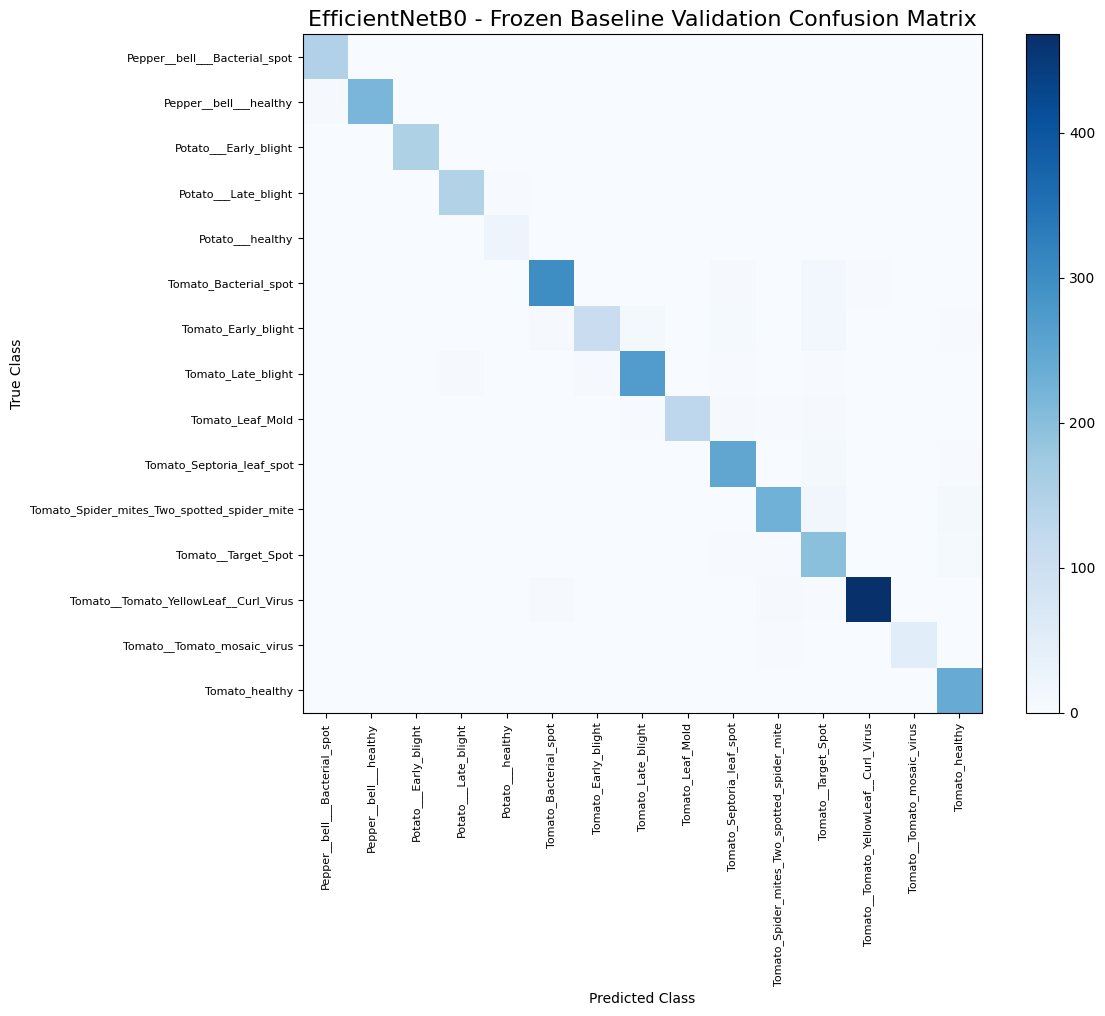

Saved to: /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/efficientnetb0_baseline_val_cm.png


In [73]:
# BASELINE VALIDATION CONFUSION MATRIX

baseline_cm = confusion_matrix(
    baseline_true_labels,
    baseline_predictions
)

plt.figure(figsize=(12, 10))

plt.imshow(
    baseline_cm,
    interpolation="nearest",
    cmap="Blues"                 # <-- SAME THEME
)

plt.title(
    "EfficientNetB0 - Frozen Baseline Validation Confusion Matrix",
    fontsize=16
)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(class_names)),
    class_names,
    fontsize=8
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()

save_path = RESULTS_DIR / "efficientnetb0_baseline_val_cm.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", save_path)

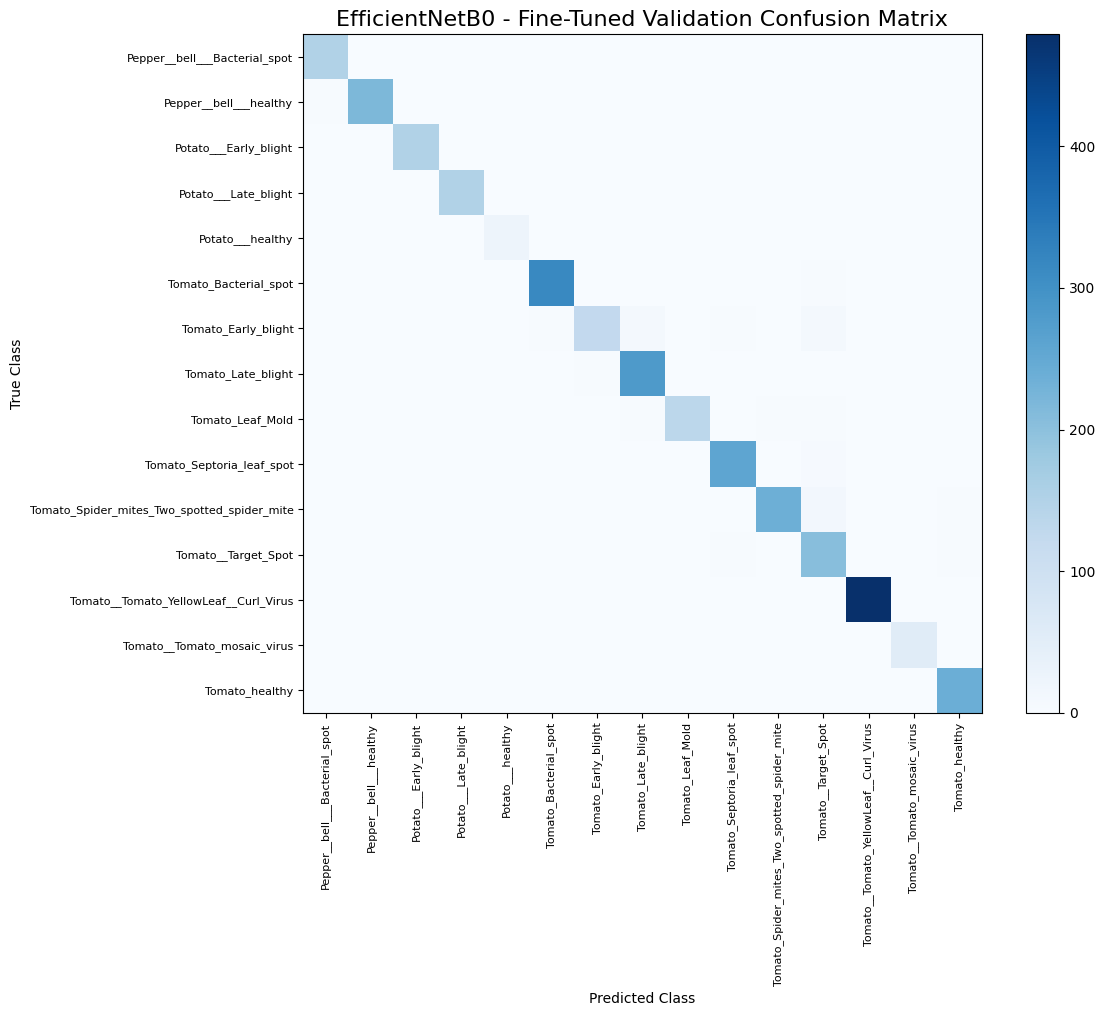

Saved to: /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/efficientnetb0_finetuned_val_cm.png


In [74]:
# FINE-TUNED VALIDATION CONFUSION MATRIX

finetuned_cm = confusion_matrix(
    finetuned_true_labels,
    finetuned_predictions
)

plt.figure(figsize=(12, 10))

plt.imshow(
    finetuned_cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.title(
    "EfficientNetB0 - Fine-Tuned Validation Confusion Matrix",
    fontsize=16
)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(class_names)),
    class_names,
    fontsize=8
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()

save_path = RESULTS_DIR / "efficientnetb0_finetuned_val_cm.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", save_path)

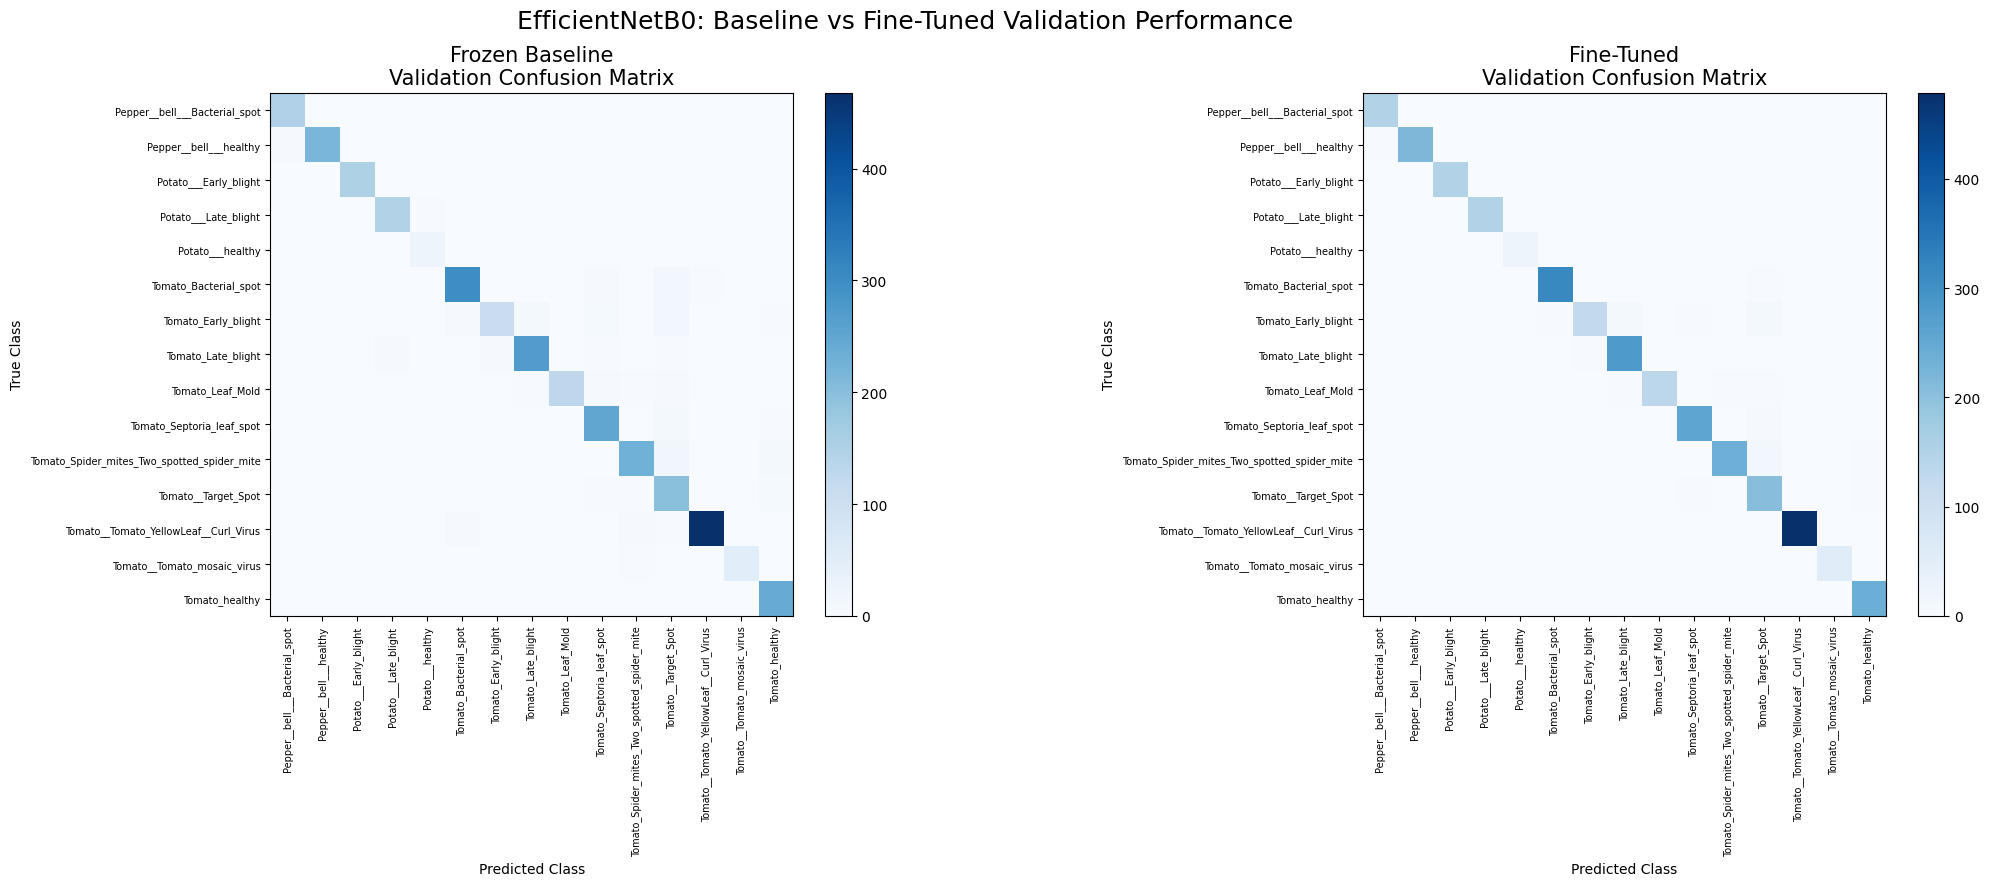

Saved to: /content/drive/MyDrive/SE4050_PlantDisease_EfficientNetB0/results/efficientnetb0_baseline_vs_finetuned_val_cm.png


In [71]:
# BASELINE VS FINE-TUNED CONFUSION MATRICES

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    1,
    2,
    figsize=(22, 9)
)

# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------

im1 = axes[0].imshow(
    baseline_cm,
    interpolation="nearest",
    cmap="Blues"
)

axes[0].set_title(
    "Frozen Baseline\nValidation Confusion Matrix",
    fontsize=15
)

axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("True Class")

axes[0].set_xticks(range(len(class_names)))
axes[0].set_yticks(range(len(class_names)))

axes[0].set_xticklabels(
    class_names,
    rotation=90,
    fontsize=7
)

axes[0].set_yticklabels(
    class_names,
    fontsize=7
)

fig.colorbar(
    im1,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)


# ------------------------------------------------------------
# Fine-tuned
# ------------------------------------------------------------

im2 = axes[1].imshow(
    finetuned_cm,
    interpolation="nearest",
    cmap="Blues"
)

axes[1].set_title(
    "Fine-Tuned\nValidation Confusion Matrix",
    fontsize=15
)

axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("True Class")

axes[1].set_xticks(range(len(class_names)))
axes[1].set_yticks(range(len(class_names)))

axes[1].set_xticklabels(
    class_names,
    rotation=90,
    fontsize=7
)

axes[1].set_yticklabels(
    class_names,
    fontsize=7
)

fig.colorbar(
    im2,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)

plt.suptitle(
    "EfficientNetB0: Baseline vs Fine-Tuned Validation Performance",
    fontsize=18
)

plt.tight_layout()

# Save to Drive (matches your project structure)
save_path = RESULTS_DIR / "efficientnetb0_baseline_vs_finetuned_val_cm.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", save_path)

In [67]:
# BASELINE VS FINE-TUNED VALIDATION METRICS
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

baseline_acc = accuracy_score(
    baseline_true_labels,
    baseline_predictions
)

finetuned_acc = accuracy_score(
    finetuned_true_labels,
    finetuned_predictions
)

baseline_precision = precision_score(
    baseline_true_labels,
    baseline_predictions,
    average="macro",
    zero_division=0
)

finetuned_precision = precision_score(
    finetuned_true_labels,
    finetuned_predictions,
    average="macro",
    zero_division=0
)

baseline_recall = recall_score(
    baseline_true_labels,
    baseline_predictions,
    average="macro",
    zero_division=0
)

finetuned_recall = recall_score(
    finetuned_true_labels,
    finetuned_predictions,
    average="macro",
    zero_division=0
)

baseline_f1 = f1_score(
    baseline_true_labels,
    baseline_predictions,
    average="macro",
    zero_division=0
)

finetuned_f1 = f1_score(
    finetuned_true_labels,
    finetuned_predictions,
    average="macro",
    zero_division=0
)

print("=" * 65)
print("BASELINE VS FINE-TUNED VALIDATION METRICS")
print("=" * 65)

print(f"{'Metric':<25} {'Baseline':>12} {'Fine-Tuned':>15}")
print("-" * 65)

print(
    f"{'Accuracy':<25}"
    f"{baseline_acc*100:>11.2f}%"
    f"{finetuned_acc*100:>14.2f}%"
)

print(
    f"{'Macro Precision':<25}"
    f"{baseline_precision*100:>11.2f}%"
    f"{finetuned_precision*100:>14.2f}%"
)

print(
    f"{'Macro Recall':<25}"
    f"{baseline_recall*100:>11.2f}%"
    f"{finetuned_recall*100:>14.2f}%"
)

print(
    f"{'Macro F1':<25}"
    f"{baseline_f1*100:>11.2f}%"
    f"{finetuned_f1*100:>14.2f}%"
)

print("=" * 65)

BASELINE VS FINE-TUNED VALIDATION METRICS
Metric                        Baseline      Fine-Tuned
-----------------------------------------------------------------
Accuracy                       94.28%         97.42%
Macro Precision                94.42%         97.64%
Macro Recall                   93.62%         97.17%
Macro F1                       93.82%         97.33%


In [68]:
# CELL: TABLE 1 - TRAINING VS VALIDATION ACCURACY

# Frozen phase
frozen_best_epoch = int(np.argmax(history_frozen.history["val_accuracy"])) + 1
frozen_train_acc  = history_frozen.history["accuracy"][frozen_best_epoch - 1]
frozen_val_acc    = history_frozen.history["val_accuracy"][frozen_best_epoch - 1]
frozen_gap        = abs(frozen_train_acc - frozen_val_acc)

# Fine-tune phase
ft_best_epoch = int(np.argmax(history_finetune.history["val_accuracy"])) + 1
ft_train_acc  = history_finetune.history["accuracy"][ft_best_epoch - 1]
ft_val_acc    = history_finetune.history["val_accuracy"][ft_best_epoch - 1]
ft_gap        = abs(ft_train_acc - ft_val_acc)

table1 = pd.DataFrame([
    {"Phase": "Frozen (EfficientNetB0)",
     "Best Epoch": frozen_best_epoch,
     "Train Acc": round(frozen_train_acc, 4),
     "Val Acc": round(frozen_val_acc, 4),
     "Gap": round(frozen_gap, 4)},
    {"Phase": "Fine-Tuned (EfficientNetB0)",
     "Best Epoch": ft_best_epoch,
     "Train Acc": round(ft_train_acc, 4),
     "Val Acc": round(ft_val_acc, 4),
     "Gap": round(ft_gap, 4)},
])

print(table1.to_string(index=False))
table1.to_csv(RESULTS_DIR / "table1_train_val_accuracy.csv", index=False)

                      Phase  Best Epoch  Train Acc  Val Acc    Gap
    Frozen (EfficientNetB0)          12     0.9394   0.9428 0.0035
Fine-Tuned (EfficientNetB0)          10     0.9839   0.9745 0.0094


In [69]:
# CELL: TABLE 2 - EVALUATION SET PERFORMANCE

from sklearn.metrics import (
    f1_score, cohen_kappa_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# Weighted F1
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

# Quadratic Weighted Kappa
qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

# Macro ROC-AUC (one-vs-rest)
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

# Re-run predictions to get probabilities
y_prob = best_model.predict(test_dataset, verbose=0)

macro_roc_auc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

table2 = pd.DataFrame([{
    "Accuracy":                 round(final_accuracy, 4),
    "Macro F1":                 round(final_f1, 4),
    "Weighted F1":              round(weighted_f1, 4),
    "Quadratic Weighted Kappa": round(qwk, 4),
    "Macro ROC-AUC":            round(macro_roc_auc, 4),
}])

print(table2.to_string(index=False))
table2.to_csv(RESULTS_DIR / "table2_evaluation_performance.csv", index=False)

 Accuracy  Macro F1  Weighted F1  Quadratic Weighted Kappa  Macro ROC-AUC
   0.9748    0.9734       0.9748                    0.9862         0.9997
